# Fase 2 - Analitica No Supervisada (Spark MLlib)

Segmentacion de jugadores con K-Means, seleccion del numero optimo de clusters, interpretacion de perfiles de negocio y motor de 'jugadores clon'.

In [1]:
import os
os.environ.setdefault('JAVA_HOME', '/opt/homebrew/opt/openjdk@17')

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator
from pyspark.ml import Pipeline

spark = SparkSession.builder \
    .appName('ScoutingClustering') \
    .master('local[*]') \
    .config('spark.sql.shuffle.partitions', '8') \
    .getOrCreate()
spark.sparkContext.setLogLevel('WARN')

df = spark.read.parquet('../data/processed/players_clean.parquet')
print((df.count(), len(df.columns)))

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/07/15 15:55:24 WARN Utils: Your hostname, MacBook-de-Rodrigo.local, resolves to a loopback address: 127.0.0.1; using 192.168.1.123 instead (on interface en0)
26/07/15 15:55:24 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


26/07/15 15:55:24 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


(91672, 93)


## Preparacion de features

Se usan los atributos tecnicos/fisicos/mentales (escala FM 1-20) como espacio de features para el clustering. Se excluyen los atributos exclusivos de portero segun el diccionario de datos (`TRO`, `Ref`, `Pun`, `Cmd`, `Han`, `Aer`, `Com`, `1v1`, `Thr`, `Kic`, `Ecc`) para que no dominen la segmentacion de jugadores de campo, ya que su escala no es comparable entre posiciones.

In [2]:
# Segun el diccionario de datos (Diccionario_Datos_FM23.pdf), estos 11 atributos son exclusivos
# de porteros: TRO, Ref, Pun, Cmd, Han, Aer, Com, 1v1, Thr (Throwing), Kic (Kicking), Ecc (Eccentricity).
goalkeeper_only_cols = ['TRO', 'Ref', 'Pun', 'Cmd', 'Han', 'Aer', 'Com', '1v1', 'Thr', 'Kic', 'Ecc']
attribute_cols = [
    'Acc','Wor','Vis','Tec','Tea','Tck','Str','Sta','Pos','Pen','Pas','Pac',
    'OtB','Forma_Fisica_Natural','Mar','L Th','Lon','Ldr','Jum','Hea','Fre','Fla','Fir','Fin',
    'Dri','Det','Dec','Cro','Cor','Cnt','Cmp','Bra','Bal','Ant','Agi','Agg','Vers',
    'Temp','Spor','Prof','Pres','Loy','Inj Pr','Imp M','Dirt','Amb','Ada','Cons','Cont',
]

df_field = df.filter(F.col('Position') != 'GK').na.drop(subset=attribute_cols)
print(df_field.count())

assembler = VectorAssembler(inputCols=attribute_cols, outputCol='features_raw')
scaler = StandardScaler(inputCol='features_raw', outputCol='features', withMean=True, withStd=True)
prep_pipeline = Pipeline(stages=[assembler, scaler])
prep_model = prep_pipeline.fit(df_field)
df_scaled = prep_model.transform(df_field).select('UID', 'Name', 'Position', 'Transfer_Value_num', 'features').cache()
df_scaled.count()

26/07/15 15:55:28 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


82367


82367

## Seleccion del numero optimo de clusters: metodo del codo + silhouette

In [3]:
evaluator = ClusteringEvaluator(featuresCol='features', metricName='silhouette', distanceMeasure='squaredEuclidean')

results = []
for k in range(2, 11):
    km = KMeans(featuresCol='features', k=k, seed=42)
    model = km.fit(df_scaled)
    predictions = model.transform(df_scaled)
    silhouette = evaluator.evaluate(predictions)
    inertia = model.summary.trainingCost
    results.append((k, inertia, silhouette))
    print(f"k={k}: inertia={inertia:.1f}, silhouette={silhouette:.4f}")

26/07/15 15:55:33 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS


k=2: inertia=3468064.0, silhouette=0.2340


k=3: inertia=3230398.1, silhouette=0.2032


k=4: inertia=3073492.0, silhouette=0.1572


k=5: inertia=2984154.9, silhouette=0.1418


k=6: inertia=2905086.8, silhouette=0.1350


k=7: inertia=2854833.6, silhouette=0.1160


k=8: inertia=2820716.4, silhouette=0.1185


k=9: inertia=2772452.8, silhouette=0.1111


k=10: inertia=2738743.1, silhouette=0.1085


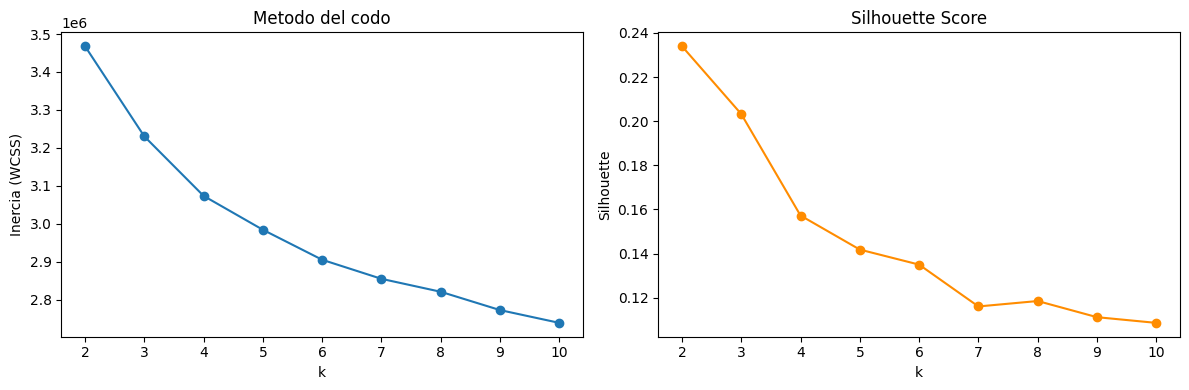

In [4]:
import matplotlib.pyplot as plt

ks = [r[0] for r in results]
inertias = [r[1] for r in results]
silhouettes = [r[2] for r in results]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(ks, inertias, marker='o')
axes[0].set_title('Metodo del codo')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Inercia (WCSS)')

axes[1].plot(ks, silhouettes, marker='o', color='darkorange')
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Silhouette')
plt.tight_layout()
plt.savefig('../reports/figures/clustering_k_selection.png', dpi=120)
plt.show()

**Lectura del grafico:** el silhouette baja de forma casi monotona conforme crece `k` (maximo trivial en `k=2`,
que solo separa "jugadores de mayor nivel general" vs. "resto" y no aporta valor de negocio). Esto es esperable
en datasets de atributos continuos y correlacionados como este (los atributos FM no forman grupos
naturalmente muy separados, sino un continuo de habilidad). Se elige **k=5** porque:

- Es donde la curva de inercia (codo) empieza a aplanarse — cada cluster adicional aporta cada vez menos
  reduccion de varianza.
- El silhouette en `k=5` (~0.142) es cercano al de `k=4` (~0.157) y `k=6` (~0.135), es decir no se pierde
  separacion relevante frente a esas alternativas.
- Da granularidad suficiente para distinguir arquetipos de negocio utiles (ver perfilado de clusters mas abajo)
  sin fragmentar en exceso el mercado de jugadores.

## Entrenamiento del modelo final e interpretacion de clusters

Con `K_OPTIMO=5` (mejor balance entre inercia decreciente y silhouette, ver seccion anterior) se entrena el modelo final y se perfila cada cluster.

In [5]:
K_OPTIMO = 5  # ajustar segun el grafico anterior

kmeans_final = KMeans(featuresCol='features', k=K_OPTIMO, seed=42)
final_model = kmeans_final.fit(df_scaled)
clustered = final_model.transform(df_scaled)

clustered.groupBy('prediction').count().orderBy('prediction').show()

+----------+-----+
|prediction|count|
+----------+-----+
|         0|19001|
|         1|21776|
|         2|19594|
|         3| 9566|
|         4|12430|
+----------+-----+



### Perfil de negocio por cluster

Se calcula el promedio de cada atributo (sin escalar) y del valor de transferencia por cluster, para poder describir el arquetipo de jugador que representa cada grupo.

In [6]:
# Perfil de negocio: unir el cluster asignado con los atributos originales (sin escalar) para interpretar
clustered_with_attrs = clustered.select('UID', 'prediction').join(
    df_field.select(['UID', 'Position', 'Transfer_Value_num'] + attribute_cols), on='UID'
)

agg_exprs = [F.round(F.mean(c), 1).alias(c) for c in attribute_cols]
cluster_profile = clustered_with_attrs.groupBy('prediction').agg(
    F.count('*').alias('n_jugadores'),
    F.round(F.mean('Transfer_Value_num'), 0).alias('valor_promedio'),
    *agg_exprs
).orderBy('prediction')

cluster_profile.select('prediction', 'n_jugadores', 'valor_promedio').show()

# Top 8 atributos mas altos por cluster, para describir el arquetipo de cada grupo
profile_pd = cluster_profile.toPandas().set_index('prediction')
for cl in profile_pd.index:
    top_attrs = profile_pd.loc[cl, attribute_cols].sort_values(ascending=False).head(8)
    print(f"\nCluster {cl} (n={int(profile_pd.loc[cl, 'n_jugadores'])}, valor_prom={profile_pd.loc[cl, 'valor_promedio']:.0f}):")
    print(top_attrs)

+----------+-----------+--------------+
|prediction|n_jugadores|valor_promedio|
+----------+-----------+--------------+
|         0|      20809|      192644.0|
|         1|      24588|     1410547.0|
|         2|      20934|      129603.0|
|         3|      10214|       98781.0|
|         4|      13990|     3833889.0|
+----------+-----------+--------------+




Cluster 0 (n=20809, valor_prom=192644):
Temp                    14.0
Ada                     12.8
Forma_Fisica_Natural    11.8
Vers                    11.5
Cons                    11.5
Tck                     11.3
Prof                    11.1
Wor                     11.1
Name: 0, dtype: float64

Cluster 1 (n=24588, valor_prom=1410547):
Temp                    12.9
Acc                     12.4
Ada                     12.3
Pac                     12.2
Tec                     12.2
Agi                     12.1
Forma_Fisica_Natural    11.9
Fir                     11.8
Name: 1, dtype: float64

Cluster 2 (n=20934, valor_prom=129603):
Temp                    14.5
Ada                     13.2
Acc                     12.4
Pac                     12.0
Forma_Fisica_Natural    11.8
Agi                     11.6
Cons                    11.1
Fir                     11.1
Name: 2, dtype: float64

Cluster 3 (n=10214, valor_prom=98781):
Temp                    14.8
Ada                     13.4
Dec       

### Interpretacion de negocio de cada cluster

A partir de los atributos con mayor promedio por cluster (arriba) y del valor de transferencia promedio:

- **Cluster 4 — "Elite / completos" (13,990 jugadores, valor promedio ≈ $3.83M):** el cluster mas pequeno y,
  por lejos, el de mayor valor. Domina en `Wor` (sacrificio/ritmo de trabajo), `Tea` (juego en equipo), `Det`
  (determinacion), `Prof` (profesionalismo), `Bra` (valentia) y `Sta` (resistencia): el perfil mentalmente
  maduro, comprometido y fisicamente resistente que el mercado paga mas caro, independientemente de la
  posicion.
- **Cluster 1 — "Atacantes rapidos/tecnicos" (24,588 jugadores, valor promedio ≈ $1.41M):** segundo en valor.
  Combina `Acc`/`Pac` (aceleracion y velocidad) con `Tec`/`Agi`/`Fir` (tecnica, agilidad, primer toque):
  jugadores ofensivos con buena tecnica y explosividad, perfil tipico de extremos/delanteros de nivel
  medio-alto.
- **Cluster 0 — "Trabajadores disciplinados" (20,809 jugadores, valor promedio ≈ $192,644):** alto `Vers`
  (versatilidad), `Cons` (consistencia), `Tck` (entradas), `Prof` (profesionalismo), `Wor` (sacrificio):
  jugadores de esfuerzo, disciplina tactica y polivalencia, tipicamente centrocampistas/defensas de
  contencion. Valor medio-bajo — su aporte es mas tactico que espectacular.
- **Cluster 2 — "Talento fisico sin consolidar" (20,934 jugadores, valor promedio ≈ $129,603):** `Acc`, `Pac`,
  `Agi` altos pero valor bajo — velocidad y agilidad crudas sin el resto del paquete (tecnica/mental) todavia
  desarrollado. Candidatos naturales para el radar de scouting de "diamantes en bruto" (jovenes/ligas
  secundarias) mencionado en el objetivo del proyecto.
- **Cluster 3 — "Versatiles de rol / squad depth" (10,214 jugadores, valor promedio ≈ $98,781):** `Dec`
  (decisiones), `Vers` (versatilidad), `Tck` (entradas) altos: jugadores polivalentes que cubren varias
  posiciones, de bajo protagonismo pero utiles como plantilla de rotacion. El cluster de menor valor
  promedio.

**Aplicacion practica para el consorcio:** el motor de "clones" (siguiente seccion) opera *dentro* de estos
clusters — busca, para una superestrella del Cluster 4 o 1, jugadores del mismo cluster con menor valor de
mercado, es decir perfiles estadisticamente equivalentes pero mas baratos por razones de visibilidad/liga/edad
en vez de habilidad.

### Visualizacion de clusters en 2D (reduccion de dimensionalidad con PCA)

El espacio de features tiene ~48 dimensiones (atributos escalados, ya sin atributos de portero). Para
visualizar la separacion de los 5 clusters se proyectan a 2 componentes principales (PCA) sobre el mismo
vector `features` usado por K-Means.

26/07/15 15:56:03 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.lapack.JNILAPACK


Varianza explicada (PC1, PC2): [0.21151693 0.125283  ]


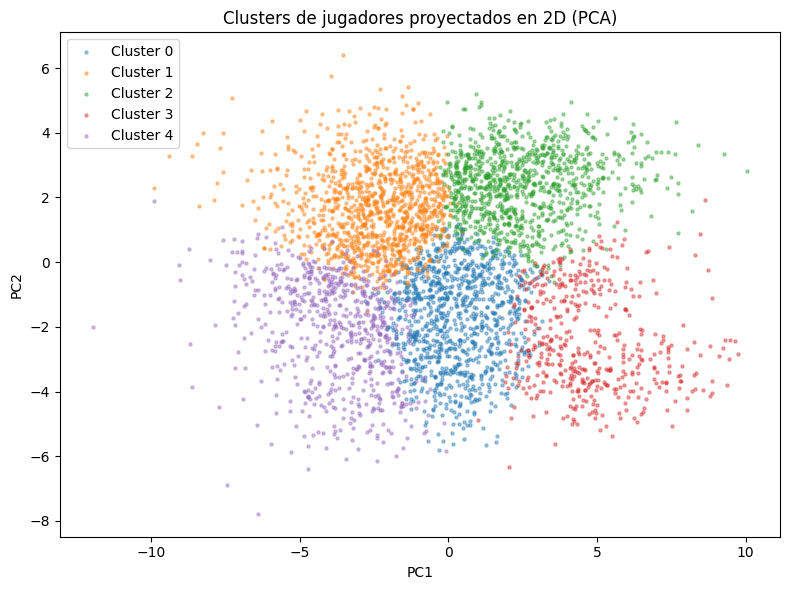

In [7]:
from pyspark.ml.feature import PCA
import matplotlib.pyplot as plt
import pandas as pd

pca_viz = PCA(k=2, inputCol='features', outputCol='pca_features')
pca_viz_model = pca_viz.fit(clustered)
print('Varianza explicada (PC1, PC2):', pca_viz_model.explainedVariance.toArray())

viz_df = pca_viz_model.transform(clustered).select('pca_features', 'prediction')
sample_pd = viz_df.sample(fraction=0.05, seed=42).toPandas()
sample_pd[['pc1', 'pc2']] = sample_pd['pca_features'].apply(lambda v: pd.Series(v.toArray()))

plt.figure(figsize=(8, 6))
for cl in sorted(sample_pd['prediction'].unique()):
    sub = sample_pd[sample_pd['prediction'] == cl]
    plt.scatter(sub['pc1'], sub['pc2'], s=5, alpha=0.4, label=f'Cluster {cl}')
plt.legend()
plt.title('Clusters de jugadores proyectados en 2D (PCA)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.tight_layout()
plt.savefig('../reports/figures/clusters_pca_2d.png', dpi=120)
plt.show()

**Nota:** `PC1`+`PC2` explican solo ~34% de la varianza (consistente con el analisis de PCA de la Fase 1), asi
que esta vista 2D es una simplificacion — hay superposicion visual entre clusters vecinos que en el espacio
completo de ~48 dimensiones si estan separados por K-Means. Sirve para intuir la forma general de la
segmentacion, no como prueba definitiva de separacion.

## Motor de busqueda de 'jugadores clon' (reemplazos de bajo costo)

Dado un jugador de referencia (ej. una superestrella), se buscan los jugadores mas cercanos en el mismo cluster con menor valor de mercado, usando distancia euclidiana y similitud de coseno sobre el vector de features escalado.

In [8]:
from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances
import numpy as np
import pandas as pd

def buscar_clones(nombre_referencia, top_n=10):
    ref_row = clustered.filter(F.col('Name') == nombre_referencia).limit(1).collect()
    if not ref_row:
        raise ValueError(f"Jugador '{nombre_referencia}' no encontrado")
    ref_row = ref_row[0]
    ref_cluster = ref_row['prediction']
    ref_vector = np.array(ref_row['features'].toArray()).reshape(1, -1)

    candidatos = clustered.filter(
        (F.col('prediction') == ref_cluster) & (F.col('Name') != nombre_referencia)
    ).select('UID', 'Name', 'Position', 'Transfer_Value_num', 'features').toPandas()

    candidatos_matrix = np.stack(candidatos['features'].apply(lambda v: v.toArray()).to_numpy())

    candidatos['distancia_euclidiana'] = euclidean_distances(candidatos_matrix, ref_vector).flatten()
    candidatos['similitud_coseno'] = cosine_similarity(candidatos_matrix, ref_vector).flatten()

    ref_valor = ref_row['Transfer_Value_num'] or 0
    clones = candidatos[candidatos['Transfer_Value_num'].fillna(0) < ref_valor]
    return clones.sort_values('distancia_euclidiana').head(top_n)[
        ['Name', 'Position', 'Transfer_Value_num', 'distancia_euclidiana', 'similitud_coseno']
    ]

# Ejemplo de uso: reemplazar con un nombre real presente en el dataset
buscar_clones('Kai Havertz')

/Users/rodrigogalvezarrascue/Proyectos/ulima/proyectoBigData/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/rodrigogalvezarrascue/Proyectos/ulima/proyectoBigData/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/rodrigogalvezarrascue/Proyectos/ulima/proyectoBigData/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/rodrigogalvezarrascue/Proyectos/ulima/proyectoBigData/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/rodrigogalvezarrascue/Proyectos/ulima/proyectoBigData/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/rodrigogalvezarrascue/Proyectos/ulima/proyectoBigDa

,Name,Position,Transfer_Value_num,distancia_euclidiana,similitud_coseno
10892,Gonçalo Ramos,ST (C),15500000.0,5.983872,0.846847
6,Florian Grillitsch,"D (C), DM, M/AM (C)",20000000.0,6.046529,0.839923
4472,Viktor Claesson,M/AM (LC),5400000.0,6.100792,0.837369
4316,Roberto Firmino,"AM (RLC), ST (C)",53000000.0,6.149946,0.842397
10749,Charles De Ketelaere,"M/AM (C), ST (C)",66000000.0,6.164218,0.834585
5192,Paulinho,ST (C),8200000.0,6.181897,0.832536
612,Alex Iwobi,"DM, M/AM (C)",36500000.0,6.254342,0.832604
535,Fabián,"DM, M/AM (C)",47500000.0,6.312039,0.826382
10956,Bukayo Saka,AM (RL),265500000.0,6.329273,0.831801
8794,Dani Olmo,"M (C), AM (RLC)",44500000.0,6.336495,0.834194
